## Notebook roadmap
This notebook reproduces **Figure 6** from the main manuscript (ladder/cylinder doublon setting, `N_d = 6`).

Figure intent:
- compare learned distances from full snapshot data and a max-entropy construction,
- show how the structure-factor peak evolves with coupling,
- visualize representative NDSS patterns at three couplings,
- export publication-ready figure assets (`figure_6.pdf`, `figure_6.svg`).


In [1]:
import os
import pickle

import numpy as np

%matplotlib widget
import matplotlib as mpl
from matplotlib import pyplot as plt

from utils.aggregation import aggregate_seeded_results


# Common settings
Set typography, line widths, and global plotting defaults used by all panels.


In [2]:
AXES_LINEWIDTH = 0.75
TICK_SIZE = 10
LABEL_SIZE = 8

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'text.latex.preamble': '\n'.join([
        r'\usepackage[semibold,sfdefault]{libertine}',
        r'\usepackage[libertine]{newtxmath}',
    ]),
    'axes.linewidth': AXES_LINEWIDTH,
})


# Distance data preparation
Load seeded distance tensors for the two data-generation pipelines and aggregate them into manuscript-ready matrices.


In [3]:
from nestconf import Configurable


class Experiment(Configurable):
    """Schema used to deserialize experiment-config keys from pickled dicts."""

    cylinder_length: int = None
    cylinder_circumference: int = None
    num_doublons: int = None


def load_seeded_bundle(data_dir):
    """Load one dataset bundle containing per-seed mean/std matrices and coordinates."""

    with open(os.path.join(data_dir, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
        seeded_f_matrices_dict = pickle.load(handle)
    with open(os.path.join(data_dir, 'seeded_f_matrices_std_dict.pickle'), 'rb') as handle:
        seeded_f_matrices_std_dict = pickle.load(handle)
    with open(os.path.join(data_dir, 'coords_dict.pickle'), 'rb') as handle:
        coords_dict = pickle.load(handle)
    return seeded_f_matrices_dict, seeded_f_matrices_std_dict, coords_dict


def aggregate_hellinger_matrix(seeded_f_matrices_dict, seeded_f_matrices_std_dict):
    """Aggregate all random seeds for the Hellinger divergence matrix."""

    divergence = 'hellinger'
    exp_config = next(iter(seeded_f_matrices_dict))
    f_matrix, _, _, _ = aggregate_seeded_results(
        seeded_f_tensors=list(seeded_f_matrices_dict[exp_config][divergence].values()),
        seeded_std_tensors=list(seeded_f_matrices_std_dict[exp_config][divergence].values()),
        verbose=True,
        use_inverse_variance_weighting=False,
    )
    return f_matrix


target_num_doublons = 6
base_data_dir = '../data/figures/figure_6'

full_data_dir = os.path.join(
    base_data_dir,
    'main_distance_matrices',
)
max_entropy_data_dir = os.path.join(
    base_data_dir,
    'max_entropy_construction',
)

# Load per-seed outputs for both constructions.
(
    full_seeded_f_matrices_dict,
    full_seeded_f_matrices_std_dict,
    full_coords_dict,
) = load_seeded_bundle(full_data_dir)
(
    max_entropy_seeded_f_matrices_dict,
    max_entropy_seeded_f_matrices_std_dict,
    max_entropy_coords_dict,
) = load_seeded_bundle(max_entropy_data_dir)

# Aggregate seeds into one matrix per construction.
full_f_matrix_all = aggregate_hellinger_matrix(
    full_seeded_f_matrices_dict,
    full_seeded_f_matrices_std_dict,
)
max_entropy_f_matrix_all = aggregate_hellinger_matrix(
    max_entropy_seeded_f_matrices_dict,
    max_entropy_seeded_f_matrices_std_dict,
)

# Manuscript panels use these fixed blocks from the aggregated matrices.
full_f_matrix = full_f_matrix_all[:61, :61]
max_entropy_f_matrix = max_entropy_f_matrix_all[:61, 61:]


Aggregating results from 3 seeds.
Aggregating results from 10 seeds.


## Load auxiliary observables
Load structure-factor and NDSS arrays used by the right-hand side panels.


In [4]:
aux_data_dir = os.path.join(base_data_dir, 'aux_files')
if not os.path.isdir(aux_data_dir):
    raise FileNotFoundError(f'Missing aux data directory: {aux_data_dir}')

# Structure factor arrays and coupling axis.
ft_szsz_list = np.load(os.path.join(aux_data_dir, 'ft_szsz.npy'))
exch_strengths_list = np.load(os.path.join(aux_data_dir, 'exch_strengths.npy'))
ft_szsz_maxes_list = np.load(os.path.join(aux_data_dir, 'ft_szsz_maxes.npy'))

# NDSS tensors for hex-panel rendering.
og_ndss_list = np.load(os.path.join(aux_data_dir, 'og_ndss_list.npy'))
max_entropy_ndss_list = np.load(os.path.join(aux_data_dir, 'max_entropy_ndss_list.npy'))


## Plotting helper functions
Define small reusable helpers for hex-lattice rendering, matrix-axis ticks, and compact colorbar endpoint labels.


In [5]:
def plot_hex_from_mat6(ax_hex, mat6, abs_vmax):
    """Render a 6-site ring graph where edge color encodes pair value from `mat6`."""

    n = 6
    # Use a fixed symmetric scale chosen for the displayed Figure 6 hex panels.
    vmin = -float(abs_vmax)
    vmax = float(abs_vmax)
    cmap = plt.get_cmap('bwr')

    angles = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False) + np.pi / 2.0
    xs = np.cos(angles)
    ys = np.sin(angles)

    def val_to_color(val):
        norm = (val - vmin) / (vmax - vmin)
        return cmap(float(np.clip(norm, 0.0, 1.0)))

    ax_hex.scatter(xs, ys, color='k', s=5, zorder=5)

    # Draw nearest-, next-nearest-, and opposite-site links.
    for dist, lw, z in [(1, 2.0, 3), (2, 2.0, 2), (3, 2.0, 1)]:
        for k in range(n):
            i = k
            j = (k + dist) % n
            if dist == 3 and j < i:
                continue
            val = float(mat6[i, j])
            ax_hex.plot([xs[i], xs[j]], [ys[i], ys[j]], color='0.5', linewidth=lw, zorder=z - 0.5)
            ax_hex.plot([xs[i], xs[j]], [ys[i], ys[j]], color=val_to_color(val), linewidth=lw, zorder=z)

    ax_hex.set_aspect('equal')
    ax_hex.set_xlim(-1.05, 1.05)
    ax_hex.set_ylim(-1.05, 1.05)
    ax_hex.margins(x=0.0, y=0.0)
    ax_hex.axis('off')


def set_param_ticks_for_matrix_ax(ax, exch_strengths, num_ticks=3, tick_size=10):
    """Place evenly spaced index ticks and label them with physical J/t values."""

    n = len(exch_strengths)
    tick_pos = np.linspace(0, n - 1, num_ticks).round().astype(int)
    tick_lbl = [f'{exch_strengths[i]:.2g}' for i in tick_pos]

    ax.set_xticks(tick_pos)
    ax.set_yticks(tick_pos)
    ax.set_xticklabels(tick_lbl, fontsize=tick_size)
    ax.set_yticklabels(tick_lbl, fontsize=tick_size)


def format_end_ticks_vertical_cbar(cbar, tick_size, label):
    """Show only endpoint numeric labels on a vertical colorbar."""

    vmin, vmax = cbar.mappable.get_clim()
    cbar.set_ticks([vmin, vmax])
    cbar.ax.set_yticklabels([])
    cbar.ax.yaxis.set_ticks_position('right')
    cbar.ax.tick_params(axis='y', right=True, length=2)

    cbar.ax.text(0.5, 1.00, f'{vmax:.2f}', transform=cbar.ax.transAxes, ha='center', va='bottom', fontsize=tick_size)
    cbar.ax.text(0.5, 0.00, f'{vmin:.2f}', transform=cbar.ax.transAxes, ha='center', va='top', fontsize=tick_size)

    cbar.set_label(label, fontsize=LABEL_SIZE, rotation=90)
    cbar.ax.yaxis.set_label_coords(-3.0, 0.5)


# Build and export figure
Assemble all Figure 6 panels, apply consistent annotations/colorbars, and save PDF/SVG outputs.


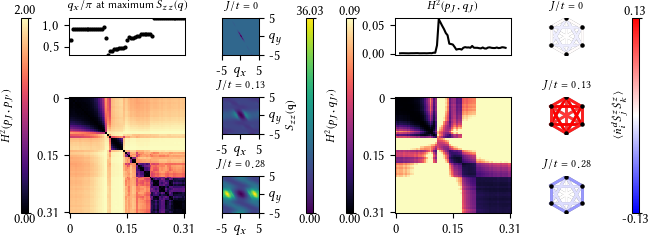

In [8]:
FIG_WIDTH_CM = 16.5
FIG_HEIGHT_CM = 6.0
CM_TO_INCH = 1.0 / 2.54

fig = plt.figure(
    figsize=(FIG_WIDTH_CM * CM_TO_INCH, FIG_HEIGHT_CM * CM_TO_INCH),
    constrained_layout=True,
)
fig.set_constrained_layout_pads(w_pad=0.005, h_pad=0.001, wspace=0.01, hspace=0.005)

grid_spec = fig.add_gridspec(
    nrows=3,
    ncols=8,
    height_ratios=[1, 1, 1],
    width_ratios=[0.075, 1.25, 0.95, 0.075, 0.075, 1.25, 0.95, 0.075],
)

peak_pos_ax = fig.add_subplot(grid_spec[0, 1:2])
full_dist_matrix_ax = fig.add_subplot(grid_spec[1:, 1:2])
structure_factor_axes = [
    fig.add_subplot(grid_spec[0, 2:3]),
    fig.add_subplot(grid_spec[1, 2:3]),
    fig.add_subplot(grid_spec[2, 2:3]),
]
max_entropy_diag_dist_ax = fig.add_subplot(grid_spec[0, 5:6])
max_entropy_dist_matrix_ax = fig.add_subplot(grid_spec[1:, 5:6])
true_ndss_axes = [
    fig.add_subplot(grid_spec[0, 6:7]),
    fig.add_subplot(grid_spec[1, 6:7]),
    fig.add_subplot(grid_spec[2, 6:7]),
]

cax_full_dist = fig.add_subplot(grid_spec[:, 0:1])
cax_sf = fig.add_subplot(grid_spec[:, 3:4])
cax_maxent_dist = fig.add_subplot(grid_spec[:, 4:5])
cax_ndss = fig.add_subplot(grid_spec[:, 7:8])

full_im = full_dist_matrix_ax.matshow(full_f_matrix, cmap='magma')
full_dist_matrix_ax.xaxis.tick_bottom()
set_param_ticks_for_matrix_ax(full_dist_matrix_ax, exch_strengths_list, num_ticks=3, tick_size=TICK_SIZE)

n_q = 51
qy_grid = np.linspace(0.0, 5.0, n_q)
qy_at_max = qy_grid[np.asarray(ft_szsz_maxes_list, dtype=int)] / np.pi
peak_pos_ax.plot(exch_strengths_list, qy_at_max, color='k', marker='o', linestyle='None', ms=2)
peak_pos_ax.set_title(r'$q_x/\pi$ at maximum $S_{zz}(q)$', fontsize=LABEL_SIZE)
peak_pos_ax.set_xticks([])
peak_pos_ax.margins(x=0.0, y=0.0)
peak_pos_ax.tick_params(axis='y', labelsize=TICK_SIZE)

qmin, qmax = -5.0, 5.0
extent = [qmin, qmax, qmin, qmax]
sf_indices = [0, 25, 55]
sf_vmax = max(float(np.abs(ft_szsz_list[idx]).max()) for idx in sf_indices)

# Choose NDSS color scale from the three matrices actually shown in this figure.
hex_panel_mats = [
    og_ndss_list[idx][1:, 1:]
    for idx in sf_indices
]
hex_vmax = max(float(np.abs(mat).max()) for mat in hex_panel_mats)

sf_im = None
for ax_idx, exch_strength_idx in enumerate(sf_indices):
    sf_im = structure_factor_axes[ax_idx].matshow(
        np.abs(ft_szsz_list[exch_strength_idx]).T,
        cmap='viridis',
        origin='lower',
        extent=extent,
        vmin=0.0,
        vmax=sf_vmax,
    )
    structure_factor_axes[ax_idx].xaxis.tick_bottom()
    structure_factor_axes[ax_idx].yaxis.tick_right()
    structure_factor_axes[ax_idx].set_xticks([-5, 0, 5])
    structure_factor_axes[ax_idx].set_xticklabels(['-5', r'$q_x$', '5'])
    structure_factor_axes[ax_idx].set_yticks([-5, 0, 5])
    structure_factor_axes[ax_idx].set_yticklabels(['-5', r'$q_y$', '5'])
    structure_factor_axes[ax_idx].tick_params(labelsize=TICK_SIZE)
    structure_factor_axes[ax_idx].set_title(
        f'$J/t = {exch_strengths_list[exch_strength_idx]:.2g}$',
        fontsize=LABEL_SIZE,
    )

max_entropy_diag_dist_ax.plot(np.diag(max_entropy_f_matrix), color='k')
max_entropy_diag_dist_ax.set_xticks([])
max_entropy_diag_dist_ax.set_title(r'$H^2(p_J, q_J)$', fontsize=LABEL_SIZE)

maxent_im = max_entropy_dist_matrix_ax.matshow(max_entropy_f_matrix, cmap='magma', vmax=0.09)
max_entropy_dist_matrix_ax.xaxis.tick_bottom()
set_param_ticks_for_matrix_ax(max_entropy_dist_matrix_ax, exch_strengths_list, num_ticks=3, tick_size=TICK_SIZE)

for row_idx, exch_strength_idx in enumerate(sf_indices):
    plot_hex_from_mat6(
        ax_hex=true_ndss_axes[row_idx],
        mat6=og_ndss_list[exch_strength_idx][1:, 1:],
        abs_vmax=hex_vmax,
    )
    true_ndss_axes[row_idx].set_title(
        f'$J/t = {exch_strengths_list[exch_strength_idx]:.2g}$',
        fontsize=LABEL_SIZE,
    )
    true_ndss_axes[row_idx].set_xticks([])
    true_ndss_axes[row_idx].set_yticks([])
    for spine in true_ndss_axes[row_idx].spines.values():
        spine.set_visible(True)

cbar_full = fig.colorbar(full_im, cax=cax_full_dist, orientation='vertical')
cbar_sf = fig.colorbar(sf_im, cax=cax_sf, orientation='vertical')
cbar_maxent = fig.colorbar(maxent_im, cax=cax_maxent_dist, orientation='vertical')

ndss_norm = mpl.colors.Normalize(vmin=-float(hex_vmax), vmax=float(hex_vmax))
ndss_mappable = mpl.cm.ScalarMappable(norm=ndss_norm, cmap=plt.get_cmap('bwr'))
ndss_mappable.set_array([])
cbar_ndss = fig.colorbar(ndss_mappable, cax=cax_ndss, orientation='vertical')

for cbar in (cbar_full, cbar_sf, cbar_maxent, cbar_ndss):
    cbar.ax.tick_params(labelsize=TICK_SIZE)

for cax in (cax_full_dist, cax_sf, cax_maxent_dist, cax_ndss):
    cax.yaxis.set_ticks_position('right')
    cax.yaxis.set_label_position('right')

cbar_labels = {
    cbar_full: r'$H^2(p_{J}, p_{J^\prime})$',
    cbar_sf: r'$S_{zz}(\mathbf{q})$',
    cbar_maxent: r'$H^2(p_{J}, q_{J^\prime})$',
    cbar_ndss: r'$\langle \hat{n}^d_i \hat{S}^z_j \hat{S}^z_k \rangle$',
}
for cbar, label in cbar_labels.items():
    format_end_ticks_vertical_cbar(cbar, tick_size=TICK_SIZE, label=label)

fig.savefig('./figure_6.pdf', pad_inches=0.00)
fig.savefig('./figure_6.svg', pad_inches=0.00)
